# Diabetes risk-stratification models

I use fixed seed 20260729 for every random operation in this notebook. I train diabetes risk-stratification models from the prepared BRFSS frame. BRFSS is cross-sectional and self-reported, so these models describe concurrent diabetes status rather than future incidence. I do not treat any model in this notebook as a mortality model.

## 1. Data and preparation

I load the prepared Parquet frame rather than re-deriving BRFSS recodes. The frame preserves 13 one-hot age bands, sex, smoking status, exercise, BMI, the primary label, and `label_sensitivity`. The primary label excludes pre-diabetes. The preparation dropped 4,631 null BMI records and retained the calculated `_TOTINDA` exercise variable because it was verified as redundant with `EXERANY2` among valid responses.

For logistic regression, I drop age band 40-44 as the arbitrary reference category so the 13 age one-hot columns do not become rank-deficient with the intercept. I also use female, never smoking, and exercise yes as explicit reference levels. The tree and K-means inputs retain all 13 age bands.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "python" / "ml"))

from train_diabetes_risk_model import (
    COEFFICIENTS_PATH,
    FIGURE_DIR,
    METRICS_PATH,
    OUTPUT_DIR,
    PROFILE_PATH,
    SEED,
    run_pipeline,
)

results = run_pipeline()
frame = results["frame"]
metrics = results["metrics"]

print(f"Fixed seed: {SEED}")
print("Shape:", frame.shape)
display(frame.dtypes.rename("dtype").to_frame())
display(frame[["label", "label_sensitivity"]].apply(lambda s: s.value_counts(dropna=False, normalize=True)))
display(results["split"])

Fixed seed: 20260729
Shape: (42766, 22)


,dtype
diabetes_response,int8
label,Int8
label_sensitivity,int8
age_band,int8
age_band_01,int8
age_band_02,int8
age_band_03,int8
age_band_04,int8
age_band_05,int8
age_band_06,int8


,label,label_sensitivity
0,0.829374,0.829374
1,0.145256,0.170626
<NA>,0.025371,NaN


,split,rows,positive_rate
0,train,33344,0.149022
1,test,8337,0.149094


The stratified split preserves the primary positive rate in both partitions. I do not report accuracy because a no-diabetes prediction for every record would score about 85 percent at the observed 14.9 percent prevalence while being useless for a pricing decision.

## 2. Logistic regression

Business decision: I use this model to support rate revision and risk assessment for a given product. Logistic regression is the primary candidate because its coefficients become directly interpretable rating factors. That is important for underwriting explanations and is a substantive reason to prefer it over a less transparent model.

I evaluate the model on the held-out test set, then refit the same specification on all primary-labelled records for the pipeline export. Calibration matters more than discrimination here because predicted probabilities feed rate calculations directly. A probability must be correct in absolute terms, not merely rank applicants well.

,feature,coefficient,std_error,z_value,p_value,significant_0_05,odds_ratio,coefficient_ci_lower_95,coefficient_ci_upper_95,odds_ratio_ci_lower_95,odds_ratio_ci_upper_95,fit_scope
0,Intercept,-5.367703,0.107477,-49.942634,0.000000e+00,True,0.004665,-5.578359,-5.157048,0.003779,0.005759,"primary labelled records, refit after held-out..."
1,age_band_01,-1.483324,0.188858,-7.854178,4.024019e-15,True,0.226882,-1.853486,-1.113163,0.156690,0.328518,"primary labelled records, refit after held-out..."
2,age_band_02,-1.271657,0.178960,-7.105795,1.196316e-12,True,0.280367,-1.622419,-0.920894,0.197421,0.398163,"primary labelled records, refit after held-out..."
3,age_band_03,-0.822441,0.143187,-5.743833,9.255711e-09,True,0.439358,-1.103087,-0.541795,0.331845,0.581703,"primary labelled records, refit after held-out..."
4,age_band_04,-0.534271,0.125568,-4.254833,2.092052e-05,True,0.586096,-0.780385,-0.288158,0.458230,0.749643,"primary labelled records, refit after held-out..."
5,age_band_06,0.516425,0.098560,5.239691,1.608459e-07,True,1.676026,0.323247,0.709604,1.381607,2.033185,"primary labelled records, refit after held-out..."
6,age_band_07,0.916852,0.091985,9.967446,2.115996e-23,True,2.501405,0.736562,1.097142,2.088743,2.995594,"primary labelled records, refit after held-out..."
7,age_band_08,1.121198,0.089077,12.586871,2.493628e-36,True,3.068527,0.946607,1.295788,2.576952,3.653874,"primary labelled records, refit after held-out..."
8,age_band_09,1.369753,0.085927,15.940935,3.293902e-57,True,3.934377,1.201336,1.538169,3.324556,4.656057,"primary labelled records, refit after held-out..."
9,age_band_10,1.423980,0.084987,16.755300,5.179890e-63,True,4.153620,1.257406,1.590555,3.516289,4.906469,"primary labelled records, refit after held-out..."


,auc,brier_score,precision_at_0_5,recall_at_0_5,f1_at_0_5,pr_auc
0,0.773308,0.111764,0.507937,0.051488,0.093499,0.346051


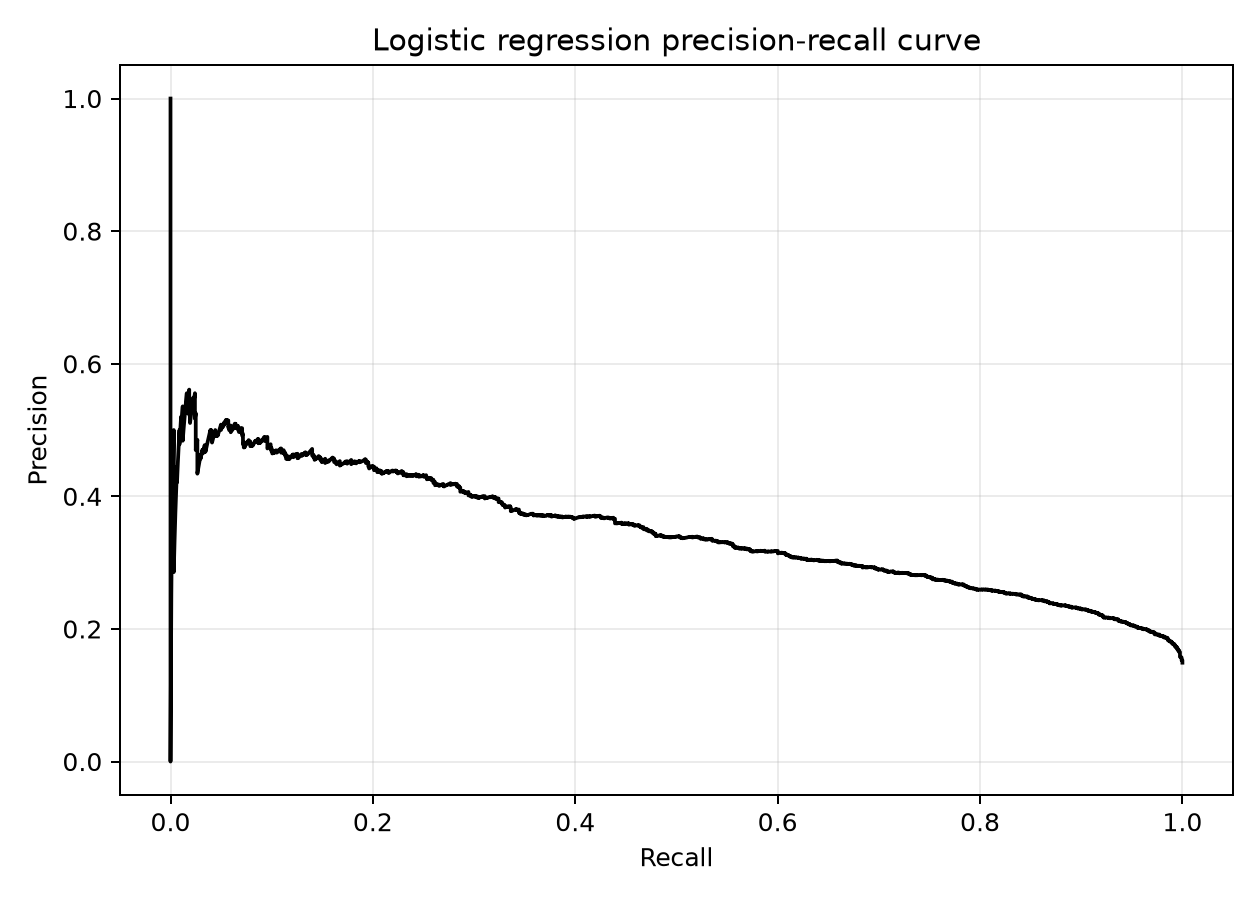

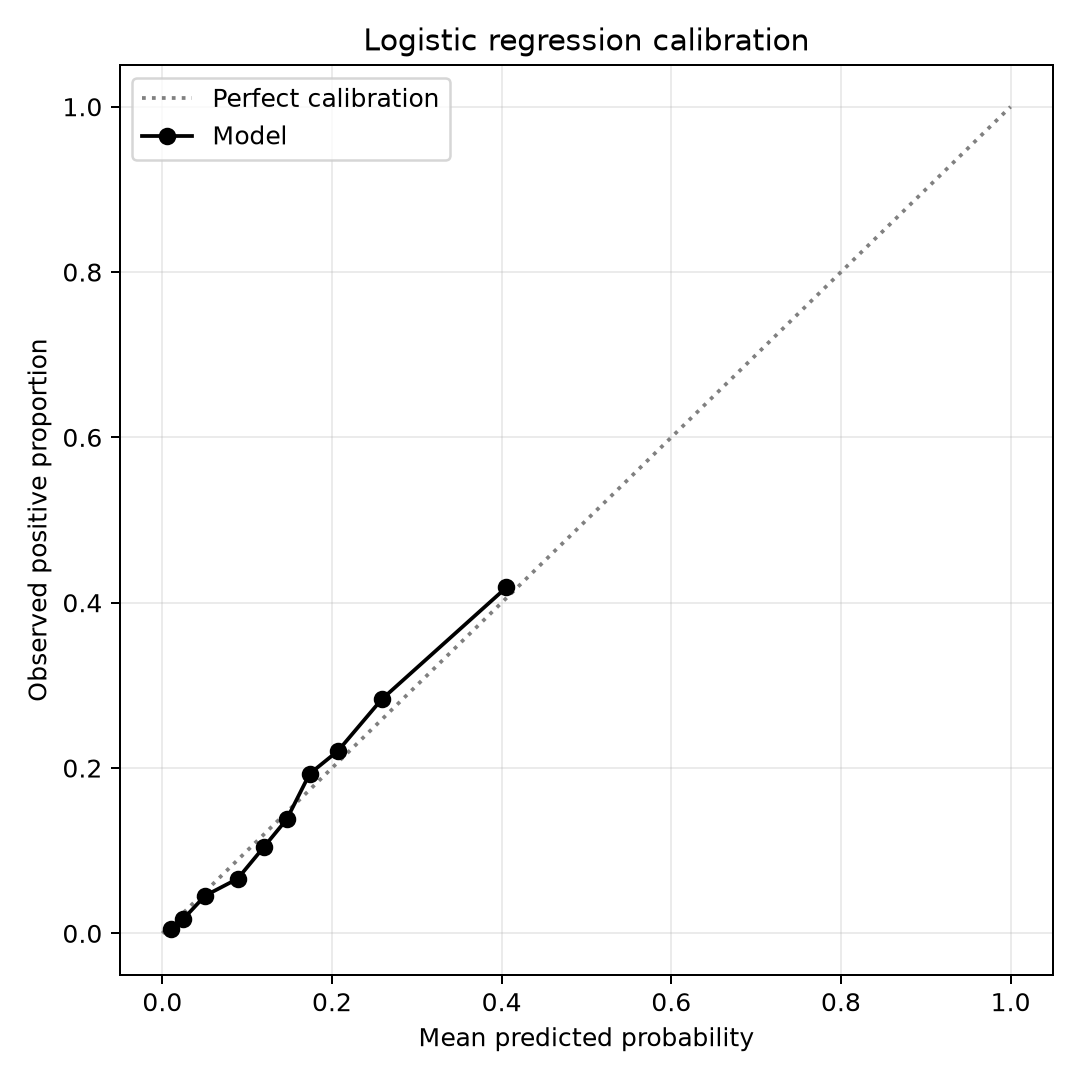

In [2]:
display(results["final_coefficients"])
display(pd.DataFrame([results["logistic_metrics"]]))
display(Image(filename=str(FIGURE_DIR / "logistic_precision_recall.png")))
display(Image(filename=str(FIGURE_DIR / "logistic_calibration.png")))

I use the model as a probability estimator, not as a yes-or-no classifier. Its continuous probability is a rating input, so the 0.5 classification threshold does not describe how the company uses it. AUC and Brier score are the operative measures. The Brier score of 0.112 improves on the 0.127 score from a constant base-rate predictor. I retain the threshold metrics because they document the fitted model, but they are not the decision criterion.

## 3. Decision tree

Business decision: I use the tree as an interpretability comparison for rate revision and risk assessment. I tune depth with five-fold stratified cross-validation on the same training split. A tree can show threshold interactions, but those thresholds are harder to defend to a regulator than a coefficient for a named risk factor.

,max_depth,cross_validation_auc
0,1,0.616331
1,2,0.652281
2,3,0.675804
3,4,0.690836
4,5,0.703440
5,6,0.715053
6,7,0.728413
7,8,0.738100


,auc,brier_score,precision_at_0_5,recall_at_0_5,f1_at_0_5,pr_auc,chosen_depth,cross_validation_auc
0,0.75509,0.113788,0.222222,0.003218,0.006344,0.300443,8,0.7381


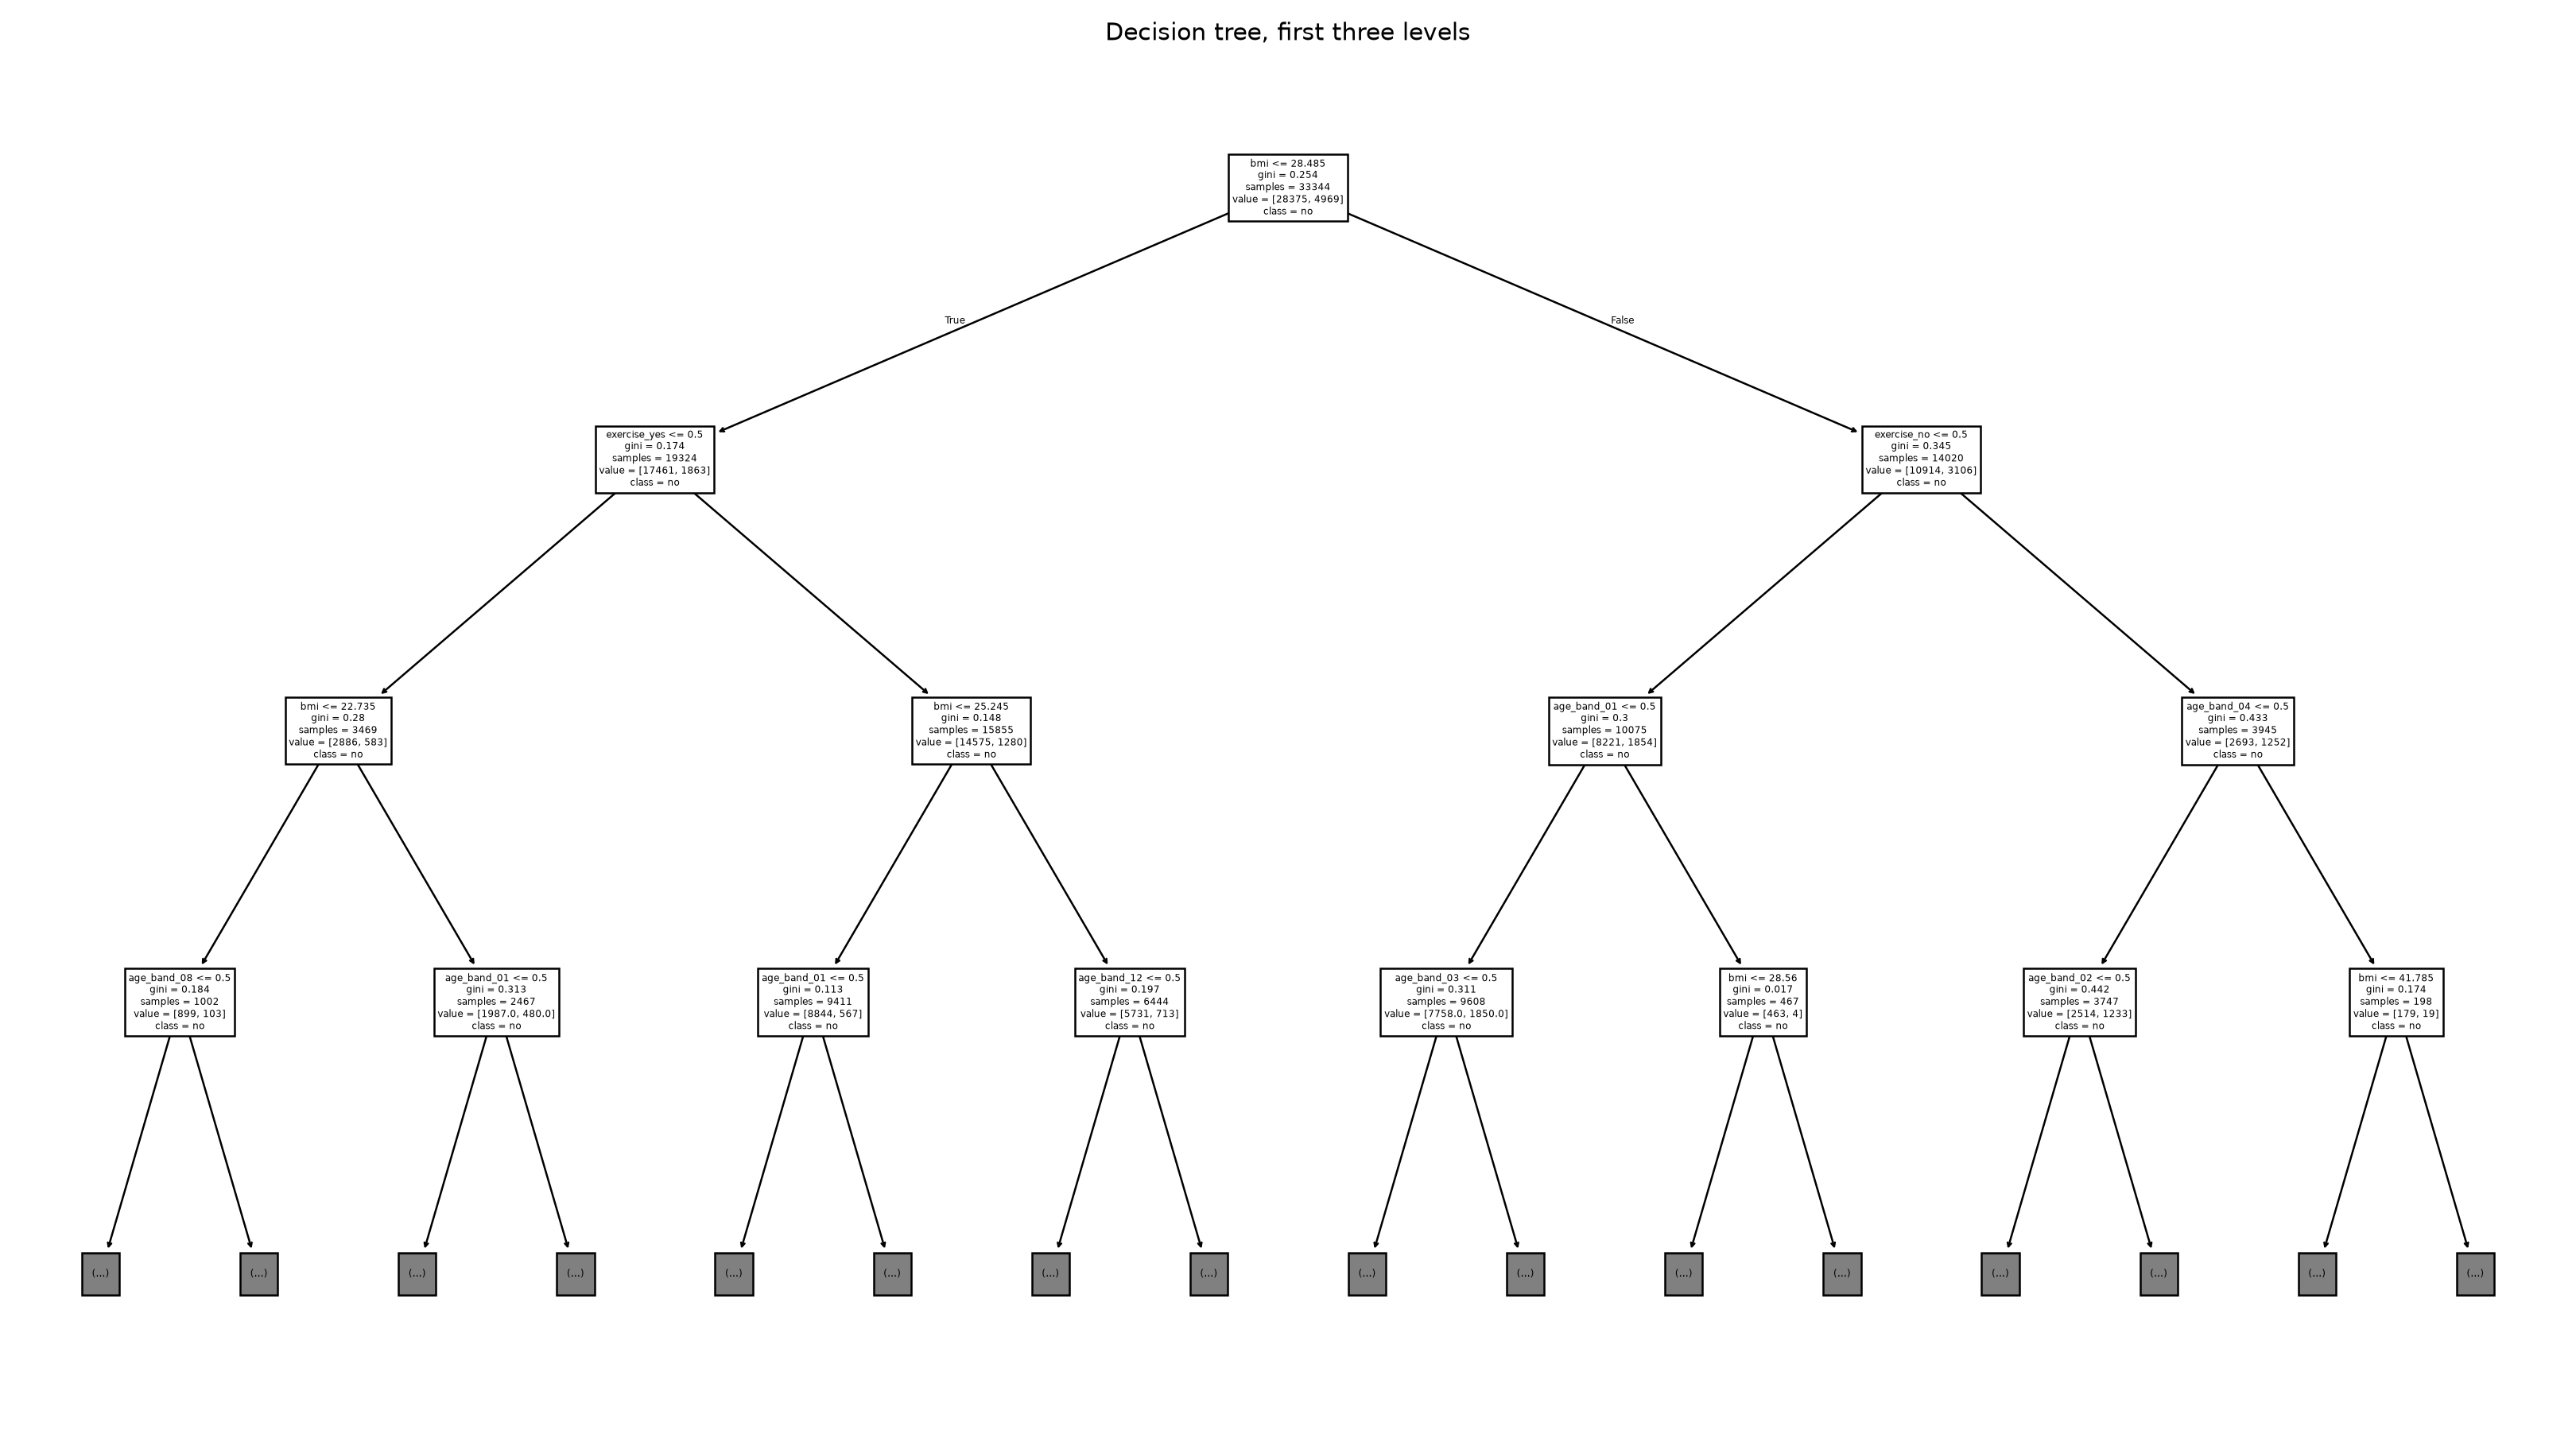

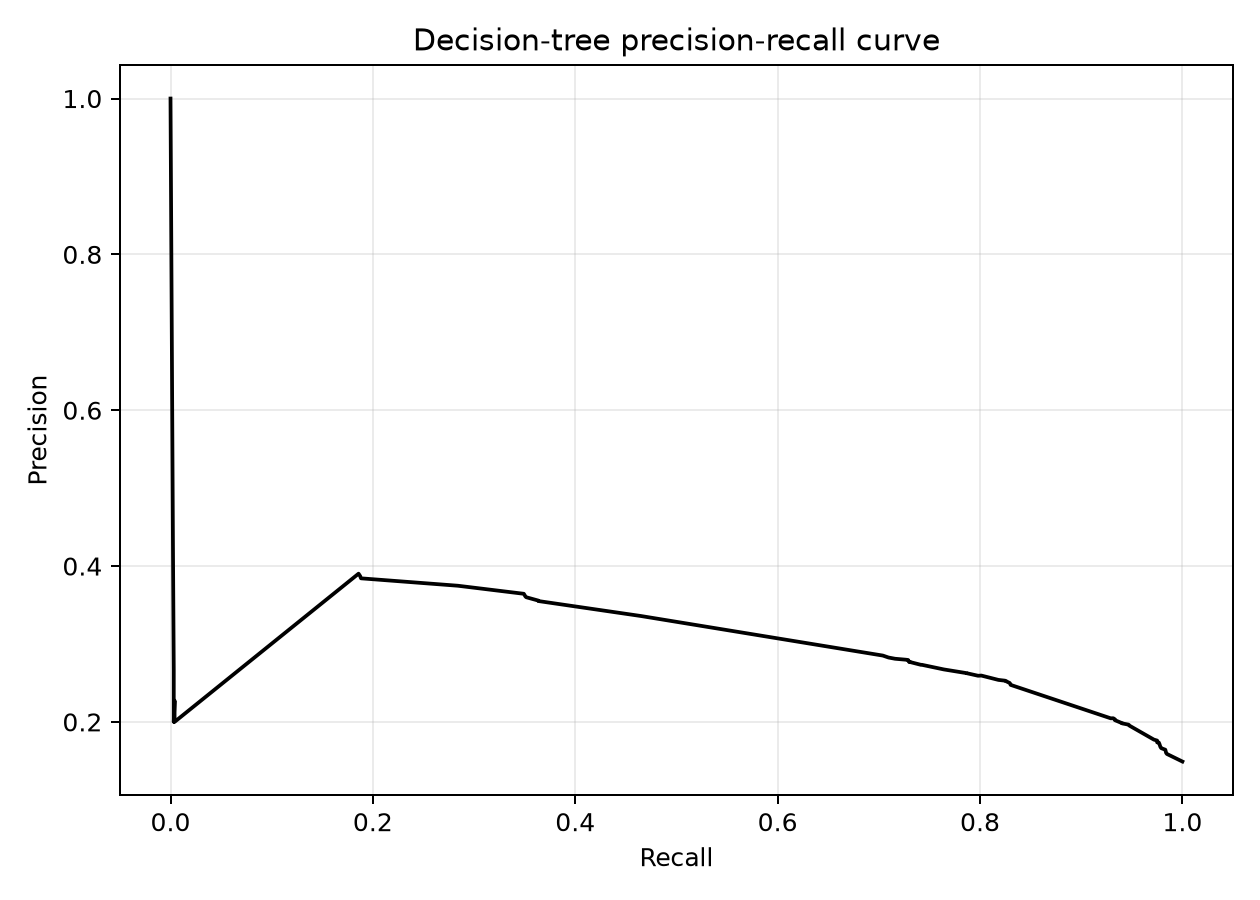

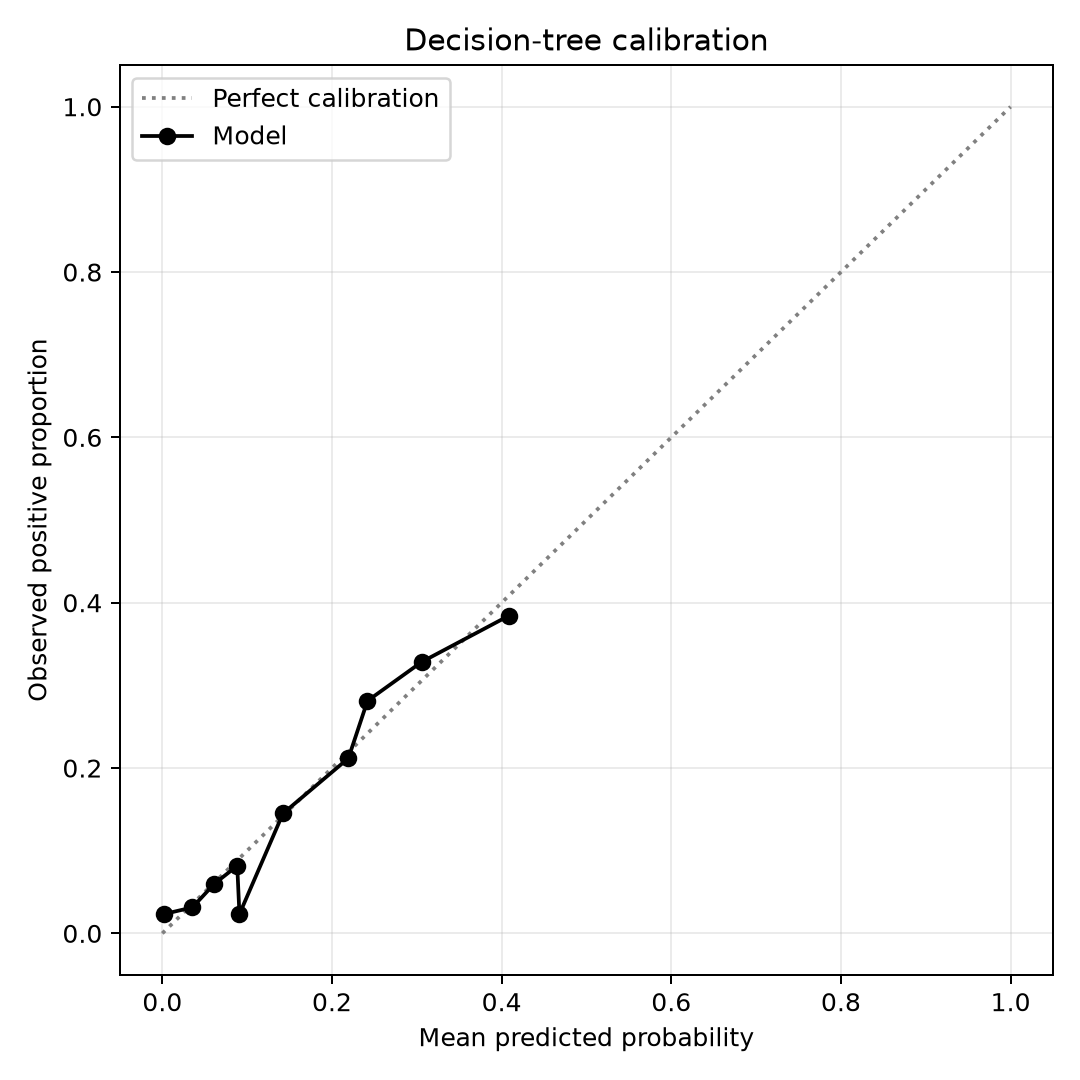

In [3]:
tree_cv = pd.DataFrame(
    {
        "max_depth": [int(k) for k in results["tree_metrics"]["cv_results"]],
        "cross_validation_auc": list(results["tree_metrics"]["cv_results"].values()),
    }
)
display(tree_cv)
display(pd.DataFrame([results["tree_metrics"]]).drop(columns=["cv_results"]))
display(Image(filename=str(FIGURE_DIR / "decision_tree_top_levels.png")))
display(Image(filename=str(FIGURE_DIR / "tree_precision_recall.png")))
display(Image(filename=str(FIGURE_DIR / "tree_calibration.png")))

I compare the held-out metrics honestly in the result table. If the tree were stronger on AUC, I would still need to explain its threshold tradeoff. In this run the tree is weaker than logistic regression, so the interpretability argument and the measured performance point in the same direction.

## 4. K-means segmentation

Business decision: I use segmentation to identify potential product tiers and wellness-outreach groups. K-means receives no diabetes label. I standardize the complete encoded feature set first because BMI and the one-hot inputs otherwise have incompatible scales. Observed diabetes prevalence appears only after fitting as a validation description.

,k,inertia,silhouette_score
0,2,809606.973439,0.140053
1,3,742676.412316,0.108788
2,4,704773.175014,0.107541
3,5,670099.554939,0.152181
4,6,635923.814024,0.148937
5,7,598652.429137,0.202894
6,8,573156.947358,0.221099


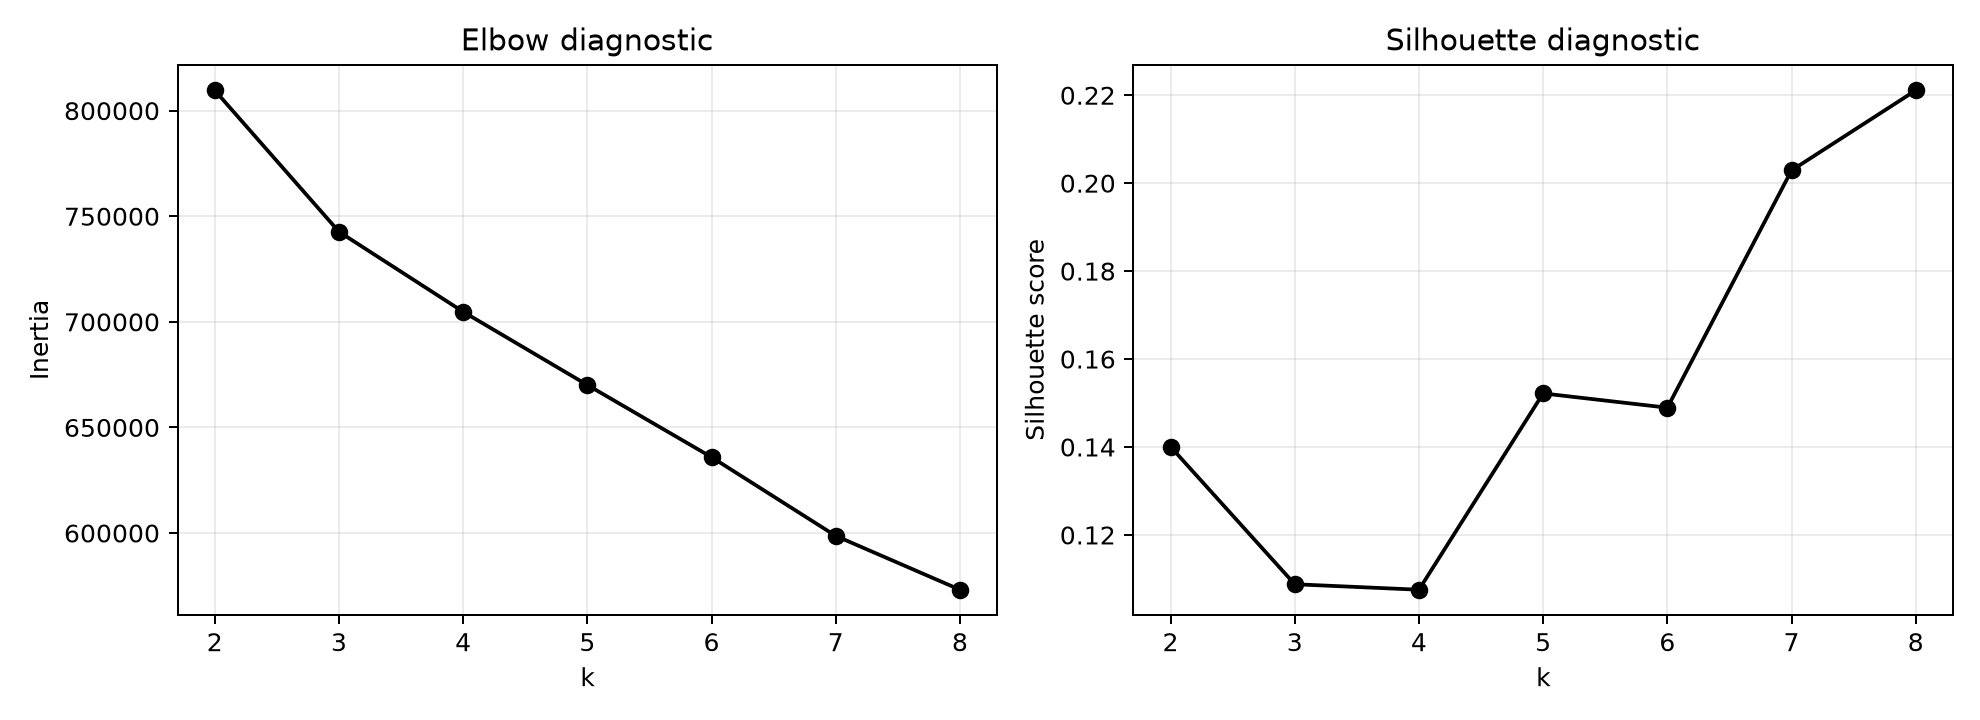

,cluster,cluster_name,size,size_percent,modal_age_band,modal_sex,modal_smoking_status,modal_exercise,mean_bmi,observed_diabetes_prevalence
0,0,"35-39 male, never smoking, yes exercise",2648,6.191835,35-39,male,never,yes,29.226103,0.042480
1,1,"50-54 male, never smoking, yes exercise",9837,23.001917,50-54,male,never,yes,28.541451,0.132792
2,2,"60-64 female, never smoking, yes exercise",4145,9.692279,60-64,female,never,yes,29.167166,0.213452
3,3,"80-99 female, never smoking, no exercise",6373,14.902025,80-99,female,never,no,30.554390,0.262388
4,4,"75-79 female, never smoking, yes exercise",3542,8.282280,75-79,female,never,yes,28.049284,0.244952
5,5,"30-34 male, never smoking, yes exercise",2405,5.623626,30-34,male,never,yes,28.807802,0.030034
6,6,"18-24 male, never smoking, yes exercise",2835,6.629098,18-24,male,never,yes,25.885786,0.011744
7,7,"65-69 female, never smoking, yes exercise",10981,25.676940,65-69,female,never,yes,27.896000,0.131879


In [4]:
k_selection = pd.DataFrame(
    {
        "k": [int(k) for k in results["kmeans_metrics"]["inertia"]],
        "inertia": list(results["kmeans_metrics"]["inertia"].values()),
        "silhouette_score": list(results["kmeans_metrics"]["silhouette"].values()),
    }
)
display(k_selection)
display(Image(filename=str(FIGURE_DIR / "kmeans_selection.png")))
display(results["clusters"])

I select the reported k using the elbow and silhouette diagnostics together. The cluster names describe their modal values and do not constitute pricing classes. A higher-BMI, lower-exercise cluster can guide wellness outreach, while simpler lower-risk clusters can guide product presentation.

K-means uses Euclidean distance, which treats all pairs of one-hot categories as equidistant. That is a poor fit for this mostly categorical data and is the main reason the silhouette score is only 0.221. K-modes or Gower distance would suit mixed data better. I retain K-means because the assignment requires it and the resulting clusters are interpretable, while stating the limitation directly.

## 5. Sparsity argument

Business decision: I need a model because a lookup table cannot give a stable rate to every profile. The staging analysis found 605 observed profiles of 624 possible. Nineteen have zero records, 34 have exactly one record, and 272 have fewer than 30 records. A single additional diabetic response changes a one-record empirical rate by 50 percentage points.

In [5]:
display(results["sparse"])
print("Zero-record lookup result: no STG_BRFSS profile row exists for this combination.")
display(results["zero"])

,AgeBand,Gender,SmokingStatus,BMIBand,ExerciseFreq,Records,EmpiricalPrevalence,PredictedProbability
0,18-24,F,current,over,no,1,0.0,0.017546
1,18-24,M,former,obese,no,1,0.0,0.043316
2,25-29,F,former,under,no,1,0.0,0.010040
3,25-29,M,former,under,no,1,0.0,0.013012
4,30-34,F,current,under,no,1,0.0,0.015365


Zero-record lookup result: no STG_BRFSS profile row exists for this combination.


,AgeBand,Gender,SmokingStatus,BMIBand,ExerciseFreq,PredictedProbability
6,18-24,F,current,under,no,0.007994


The zero-record example has no empirical prevalence to look up, yet the fitted logistic model returns a probability. This is the practical reason the company cannot price from a `STG_BRFSS` lookup table alone.

The same staging query found two one-record profiles with a diabetic response. A lookup table would assign each an empirical prevalence of 100 percent from one observation, while the fitted probabilities are much lower.

| AgeBand | Gender | SmokingStatus | BMIBand | ExerciseFreq | Records | EmpiricalPrevalence | PredictedProbability |
|---|---|---|---|---|---|---|---|
| 40-44 | M | former | under | no | 1 | 1.0000 | 0.0449 |
| 55-59 | F | never | under | no | 1 | 1.0000 | 0.0898 |

## 6. Sensitivity analysis on pre-diabetes

Business decision: I test whether the binary decision to map pre-diabetes to no in `RISK_FACTOR` changes the core rate-revision result. The sensitivity model folds the 1,085 pre-diabetes records into the positive label and uses the same logistic specification. This is a measurement of the documented source-traceability decision, not a three-level rating factor.

In [6]:
display(results["sensitivity"])
display(pd.DataFrame([results["sensitivity_metrics"]]))
print(
    "Primary AUC:", f"{results['logistic_metrics']['auc']:.3f}",
    "Sensitivity AUC:", f"{results['sensitivity_metrics']['auc']:.3f}",
)

,feature,coefficient_primary,coefficient_sensitivity,coefficient_change,sign_changed
0,Intercept,-5.295014,-5.054272,0.240742,False
1,age_band_01,-1.460276,-1.167082,0.293194,False
2,age_band_02,-1.224591,-1.065220,0.159371,False
3,age_band_03,-0.733980,-0.640178,0.093801,False
4,age_band_04,-0.607435,-0.458840,0.148595,False
5,age_band_06,0.515652,0.501365,-0.014287,False
6,age_band_07,0.861719,0.791455,-0.070264,False
7,age_band_08,1.098332,1.048320,-0.050012,False
8,age_band_09,1.341015,1.276144,-0.064871,False
9,age_band_10,1.362412,1.319564,-0.042849,False


,auc,brier_score,precision_at_0_5,recall_at_0_5,f1_at_0_5,pr_auc
0,0.75445,0.125332,0.52459,0.065753,0.116859,0.36681


Primary AUC: 0.773 Sensitivity AUC: 0.754


## 7. Validation against external sources

Business decision: I check whether the model's age pattern agrees directionally with independent external data before using it in a pricing pipeline. The first check compares predicted diabetes prevalence against the WONDER diabetes-to-all-cause ratio for the 2022-2024 cohort, identified in staging by `SourceYear = 2023`. Prevalence and mortality attribution are different measures, so I assess direction rather than numerical equality. The second check compares age ordering with lives-weighted SSA mortality rates.

,WonderAgeBand,Gender,predicted_probability,AgeBand,AllCauseRate,DiabetesRate,DiabetesToAllCauseRatio
0,15-24,F,0.011345,15-24,0.000410,0.000005,0.012195
2,25-34,F,0.022925,25-34,0.000866,0.000019,0.021940
4,35-44,F,0.052192,35-44,0.001616,0.000045,0.027847
6,45-54,F,0.127188,45-54,0.003110,0.000119,0.038264
8,55-64,F,0.183692,55-64,0.007045,0.000276,0.039177
10,65-74,F,0.205549,65-74,0.014862,0.000564,0.037949
12,75-84,F,0.226687,75-84,0.038490,0.001130,0.029358
14,85+,F,0.182927,85+,0.134781,0.002417,0.017933
1,15-24,M,0.013230,15-24,0.001062,0.000007,0.006591
3,25-34,M,0.026176,25-34,0.002021,0.000030,0.014844


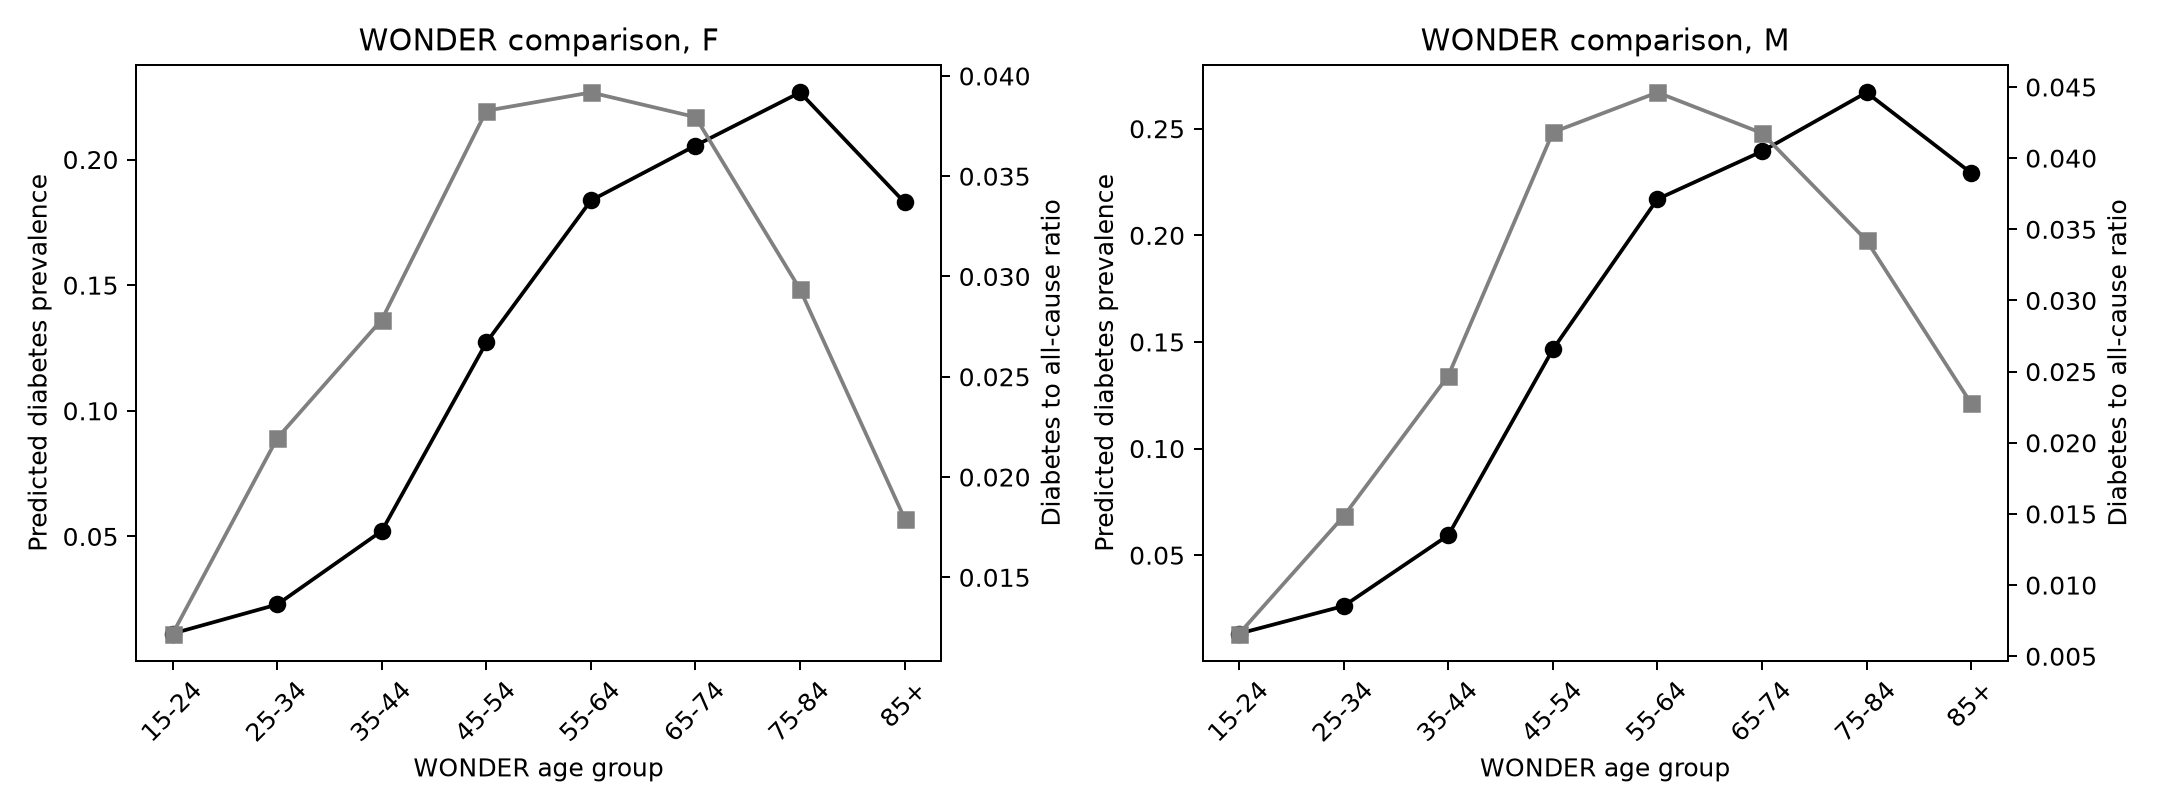

,age_band,Gender,predicted_probability,AgeBand,MortalityRate
0,1,F,0.011345,18-24,0.000477
2,2,F,0.017152,25-29,0.000696
4,3,F,0.027894,30-34,0.001017
6,4,F,0.039101,35-39,0.001358
8,5,F,0.064253,40-44,0.001851
10,6,F,0.105085,45-49,0.002463
12,7,F,0.147118,50-54,0.003576
14,8,F,0.167956,55-59,0.005389
16,9,F,0.196874,60-64,0.008208
18,10,F,0.199754,65-69,0.011751


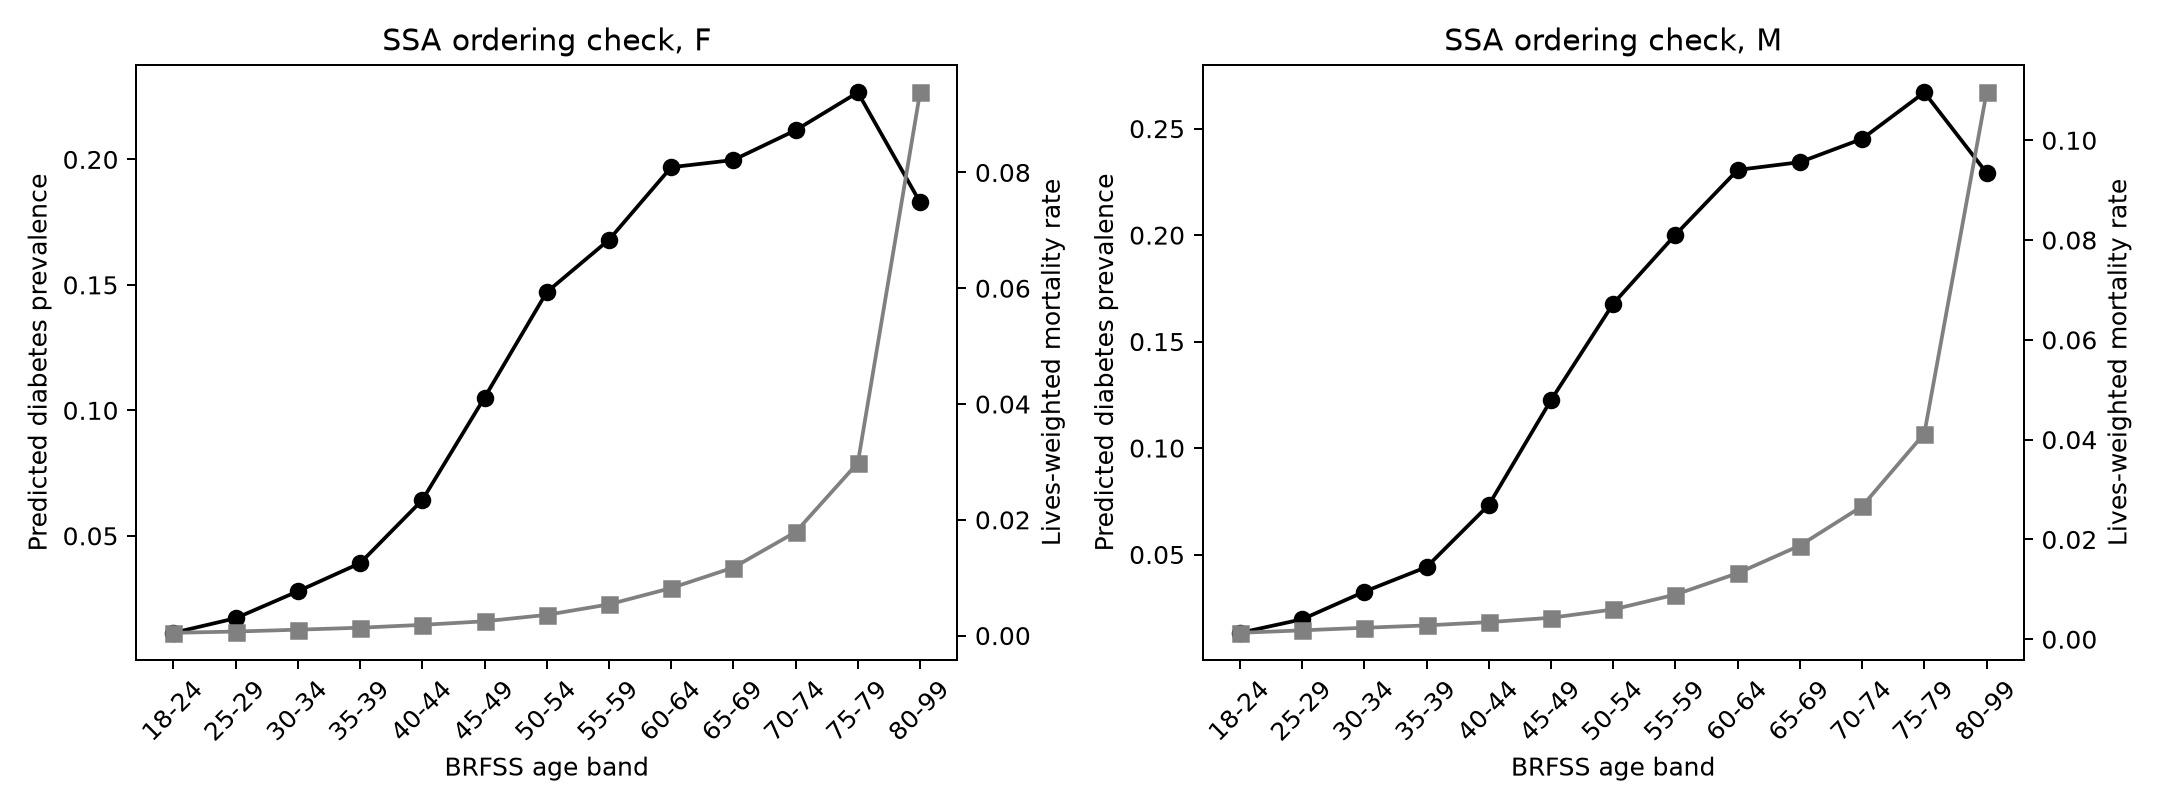

{
  "wonder_spearman_by_sex": {
    "F": 0.5952380952380953,
    "M": 0.5476190476190477
  },
  "ssa_monotonic_by_sex": {
    "F": {
      "model_non_decreasing": false,
      "ssa_non_decreasing": true
    },
    "M": {
      "model_non_decreasing": false,
      "ssa_non_decreasing": true
    }
  }
}


In [7]:
display(results["wonder_comparison"])
display(Image(filename=str(FIGURE_DIR / "wonder_directional_comparison.png")))
display(results["ssa_ordering"])
display(Image(filename=str(FIGURE_DIR / "ssa_ordering_comparison.png")))
print(json.dumps(results["validation_metrics"], indent=2))

The WONDER comparison gives positive rank correlations for both sexes. Spearman correlations are F=0.595 and M=0.548. They are directionally consistent, but eight age groups cannot support a significance claim because the approximate 0.05 critical value is 0.74. I report them as directional evidence only.

The model probability declines from 75-79 to the open-ended 80-99 band for both sexes while SSA mortality continues to rise. This is expected epidemiology rather than a model defect. Survivorship means people with diabetes can die earlier, leaving a healthier surviving population above age 80. Diabetes can also be underdiagnosed in the very old, and the open-ended 80-99 band mixes twenty years of substantially different ages. Prevalence and mortality are different quantities, so they need not move together at the oldest ages.

This result validates the source separation in the design. SSA supplies absolute mortality, while the model supplies relative differentiation rather than the mortality baseline. The same pattern helps explain the subgroup AUC of 0.652 for age 80-99 compared with 0.803 for age 35-39. The oldest band is the hardest group to discriminate for the same survivorship and aggregation reasons, as shown in the fairness results below.

## 8. Fairness and limitations

United States permissibility is jurisdiction-specific. Age, smoking status, diabetes status, and BMI are candidate rating inputs only where the company can show a sound actuarial basis and a valid rationale, then comply with applicable state law and filing rules. Gender requires separate review because its use is restricted in some United States jurisdictions and prohibited for insurance pricing in the European Union. The National Association of Insurance Commissioners states that external-data underwriting models need sound actuarial principles, transparent inputs, and unfair-discrimination review. The European Commission's Test-Achats guidance requires unisex premiums and benefits for new European Union contracts.

The frame retains 42,766 of 50,000 records, so 7,234 records do not remain after preparation. BMI accounts for 4,631 drops, and the documented nonresponse patterns mean the exclusions are a coherent less-willing respondent group rather than scattered noise. Training is unweighted, so probabilities reflect the BRFSS sample rather than the United States population. Calibration and subgroup monitoring are the controls that address that limitation.

In [8]:
display(results["sex_auc"])
display(results["age_auc"])

,subgroup,rows,positive_rows,auc
0,female,4226,613,0.770723
1,male,4111,630,0.776715


,subgroup,rows,positive_rows,auc
0,18-24,599,6,0.751546
1,25-29,430,6,0.736242
2,30-34,471,11,0.775889
3,35-39,514,24,0.802679
4,40-44,583,41,0.707677
5,45-49,537,56,0.662682
6,50-54,558,94,0.729847
7,55-59,669,121,0.692141
8,60-64,813,174,0.688459
9,65-69,885,210,0.685898


## 9. Output for the pipeline

I export the candidate logistic coefficients, one predicted probability for every possible `STG_BRFSS` profile, and the evaluation metrics. The profile export has all 624 combinations using the verified staging vocabulary `AgeBand`, `Gender`, `SmokingStatus`, `BMIBand`, and `ExerciseFreq`. It is the direct input shape for future `RISK_FACTOR` construction. This notebook does not populate `RISK_FACTOR`, `RATE_VERSION`, or `RATE`.

In [9]:
profiles = pd.read_csv(PROFILE_PATH)
print("Coefficient export:", COEFFICIENTS_PATH)
print("Profile export:", PROFILE_PATH)
print("Metrics export:", METRICS_PATH)
print("Profile shape:", profiles.shape)
print("Vocabulary:", json.dumps(metrics["profile_vocabulary"], indent=2))
display(profiles.head())

Coefficient export: /Users/jingrui_feng/Desktop/Summer2026/DB /project/part3/outputs/model/logistic_coefficients.csv
Profile export: /Users/jingrui_feng/Desktop/Summer2026/DB /project/part3/outputs/model/predicted_risk_by_profile.csv
Metrics export: /Users/jingrui_feng/Desktop/Summer2026/DB /project/part3/outputs/model/model_metrics.json
Profile shape: (624, 6)
Vocabulary: {
  "AgeBand": [
    "18-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64",
    "65-69",
    "70-74",
    "75-79",
    "80-99"
  ],
  "Gender": [
    "F",
    "M"
  ],
  "SmokingStatus": [
    "current",
    "former",
    "never"
  ],
  "BMIBand": [
    "normal",
    "obese",
    "over",
    "under"
  ],
  "ExerciseFreq": [
    "no",
    "yes"
  ]
}


,AgeBand,Gender,SmokingStatus,BMIBand,ExerciseFreq,PredictedProbability
0,18-24,F,current,normal,no,0.012100
1,18-24,F,current,normal,yes,0.006739
2,18-24,F,current,obese,no,0.033069
3,18-24,F,current,obese,yes,0.018593
4,18-24,F,current,over,no,0.017546
